<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-09-29 16:50:26--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  13.4MB/s    in 13s     
2026-09-29 16:50:42 (11.6 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [ ]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


## Demo: Listing All Tables


To view the names of all tables in the database:


In [6]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [8]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


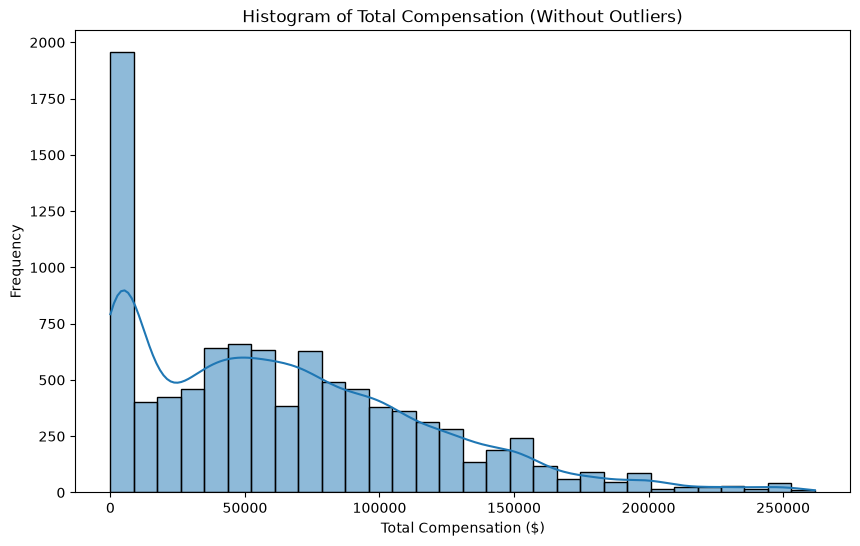

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular IQR para CompTotal
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

# 2. Filtrar sin outliers extremos
df_comp_filtered = df[df['CompTotal'] <= upper_bound]

# 3. Graficar el histograma limpio
plt.figure(figsize=(10, 6))
sns.histplot(df_comp_filtered['CompTotal'].dropna(), bins=30, kde=True)
plt.title('Histogram of Total Compensation (Without Outliers)')
plt.xlabel('Total Compensation ($)')
plt.ylabel('Frequency')

plt.savefig('temp_plot.png', bbox_inches='tight')
plt.show()

**Box Plots**

Plot a box plot of Age.


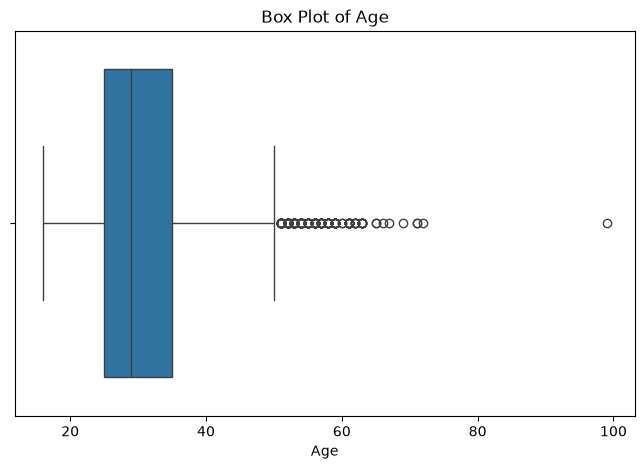

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurar conversión a numérico
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age')
plt.xlabel('Age')

plt.savefig('temp_plot.png', bbox_inches='tight')
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


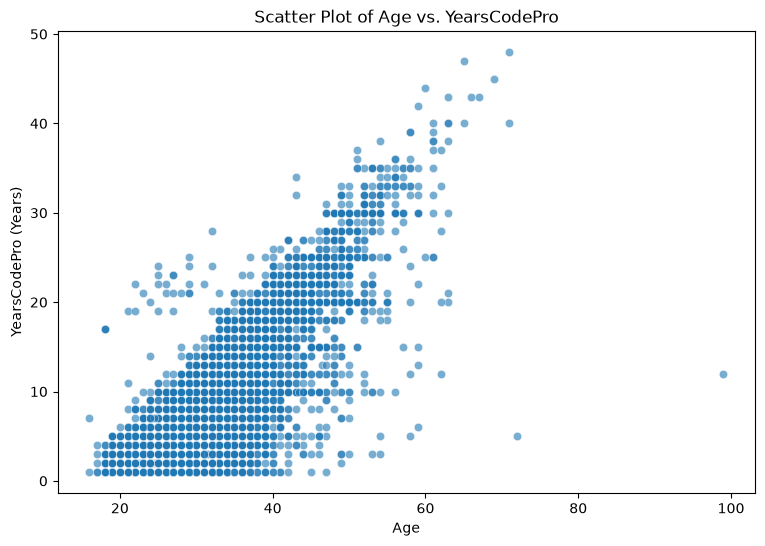

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Asegurar tipo de datos para Age
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# 2. Detectar la columna de experiencia laboral disponible
work_col = None
possible_work_cols = ['WorkExp', 'YearsCodePro', 'YearsCode']

for col in possible_work_cols:
    if col in df.columns:
        work_col = col
        break

if work_col:
    # Convertir a valor numérico
    df[work_col] = pd.to_numeric(df[work_col], errors='coerce')

    # Generar el gráfico de dispersión
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=df, x='Age', y=work_col, alpha=0.6)
    plt.title(f'Scatter Plot of Age vs. {work_col}')
    plt.xlabel('Age')
    plt.ylabel(f'{work_col} (Years)')

    plt.savefig('temp_plot.png', bbox_inches='tight')
    plt.show()
else:
    print("No se encontró una columna de experiencia laboral. Las columnas disponibles son:")
    print(df.columns.tolist())

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


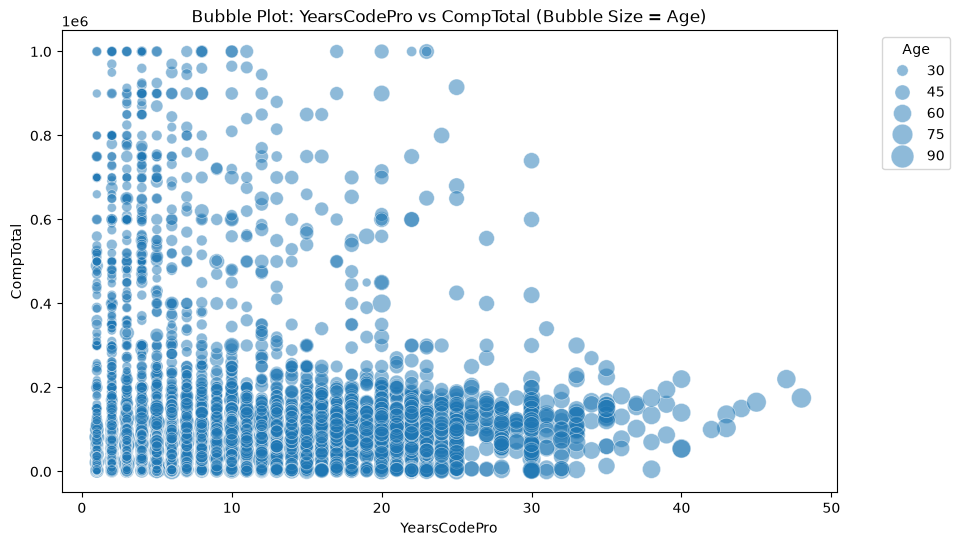

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identificar las columnas existentes para X, Y y Size
x_col = 'WorkExp' if 'WorkExp' in df.columns else ('YearsCodePro' if 'YearsCodePro' in df.columns else None)
y_col = 'ConvertedCompYearly' if 'ConvertedCompYearly' in df.columns else ('CompTotal' if 'CompTotal' in df.columns else None)
size_col = 'Age' if 'Age' in df.columns else None

if x_col and y_col and size_col:
    # Convertir a valores numéricos
    for col in [x_col, y_col, size_col]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Filtrar valores nulos
    bubble_df = df[[x_col, y_col, size_col]].dropna()

    # Opcional: Filtrar atípicos en salario para mejorar la visualización
    q_high = bubble_df[y_col].quantile(0.95)
    bubble_df = bubble_df[bubble_df[y_col] <= q_high]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=bubble_df, 
        x=x_col, 
        y=y_col, 
        size=size_col, 
        sizes=(20, 300), 
        alpha=0.5
    )
    plt.title(f'Bubble Plot: {x_col} vs {y_col} (Bubble Size = {size_col})')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title=size_col, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.savefig('temp_plot.png', bbox_inches='tight')
    plt.show()
else:
    print("Columnas disponibles en el DataFrame:")
    print(df.columns.tolist())

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


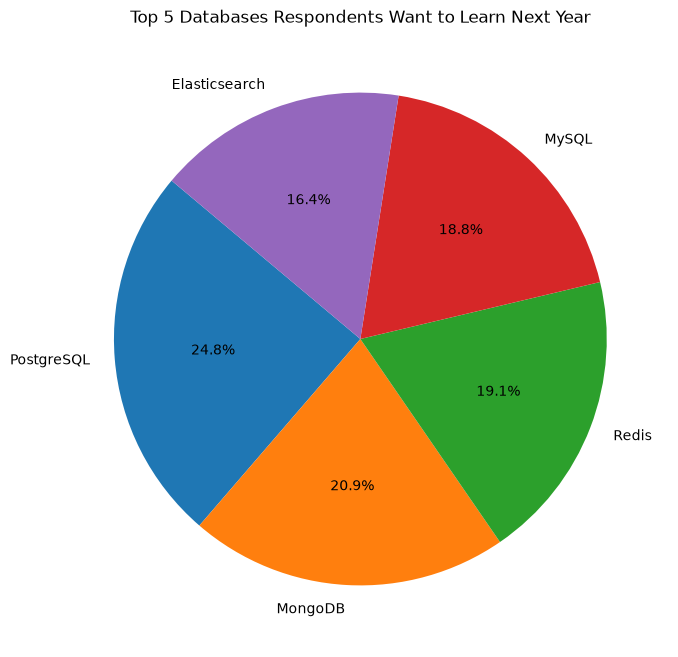

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Buscar la columna exacta de bases de datos
db_col = 'DatabaseWantToWorkWith' if 'DatabaseWantToWorkWith' in df.columns else 'DatabaseDesireNextYear'

# Separar los elementos delimitados por ';' y obtener los 5 más frecuentes
top5_db = df[db_col].dropna().str.split(';').explode().value_counts().head(5)

plt.figure(figsize=(8, 8))
plt.pie(top5_db.values, labels=top5_db.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 5 Databases Respondents Want to Learn Next Year')

plt.savefig('temp_plot.png', bbox_inches='tight')
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


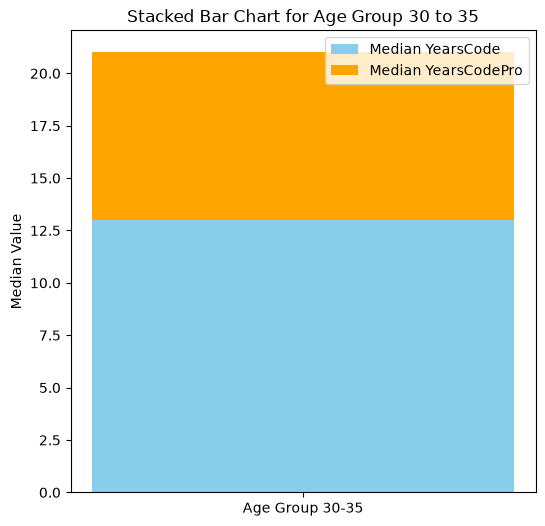

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convertir Age a numérico
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# 2. Verificar las columnas disponibles en el DataFrame
col1 = 'TimeSearching' if 'TimeSearching' in df.columns else ('WorkExp' if 'WorkExp' in df.columns else 'YearsCode')
col2 = 'TimeAnswering' if 'TimeAnswering' in df.columns else ('YearsCodePro' if 'YearsCodePro' in df.columns else 'CompTotal')

# Convertir a numérico solo si la columna existe en df
if col1 in df.columns:
    df[col1] = pd.to_numeric(df[col1], errors='coerce')
if col2 in df.columns:
    df[col2] = pd.to_numeric(df[col2], errors='coerce')

# 3. Filtrar para el grupo de edad de 30 a 35 años
age_30_35 = df[(df['Age'] >= 30) & (df['Age'] <= 35)]

# 4. Calcular medianas
med1 = age_30_35[col1].median() if col1 in age_30_35.columns else 0
med2 = age_30_35[col2].median() if col2 in age_30_35.columns else 0

# 5. Generar gráfico de barras apiladas
plt.figure(figsize=(6, 6))
plt.bar(['Age Group 30-35'], [med1], label=f'Median {col1}', color='skyblue')
plt.bar(['Age Group 30-35'], [med2], bottom=[med1], label=f'Median {col2}', color='orange')

plt.title('Stacked Bar Chart for Age Group 30 to 35')
plt.ylabel('Median Value')
plt.legend()

plt.savefig('temp_plot.png', bbox_inches='tight')
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


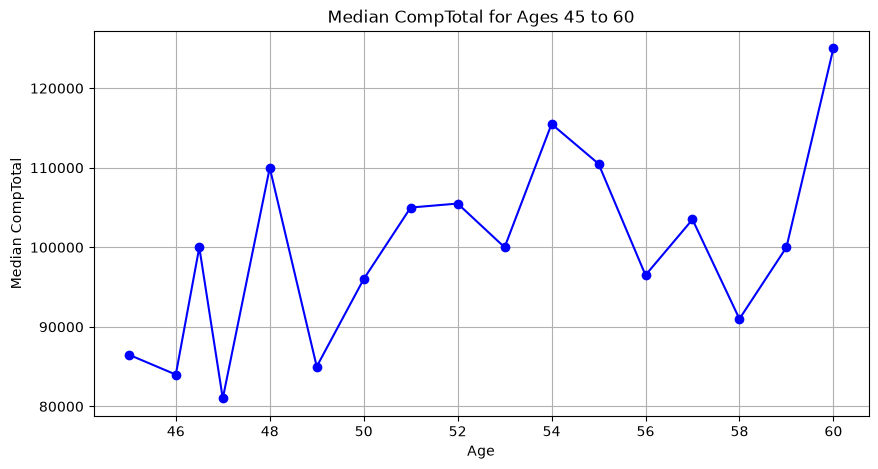

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

comp_col = 'CompTotal' if 'CompTotal' in df.columns else 'ConvertedCompYearly'

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
if comp_col in df.columns:
    df[comp_col] = pd.to_numeric(df[comp_col], errors='coerce')

df_line = df[(df['Age'] >= 45) & (df['Age'] <= 60)]
median_comp = df_line.groupby('Age')[comp_col].median().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(median_comp['Age'], median_comp[comp_col], marker='o', color='b', linestyle='-')
plt.title(f'Median {comp_col} for Ages 45 to 60')
plt.xlabel('Age')
plt.ylabel(f'Median {comp_col}')
plt.grid(True)

plt.savefig('temp_plot.png', bbox_inches='tight')
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


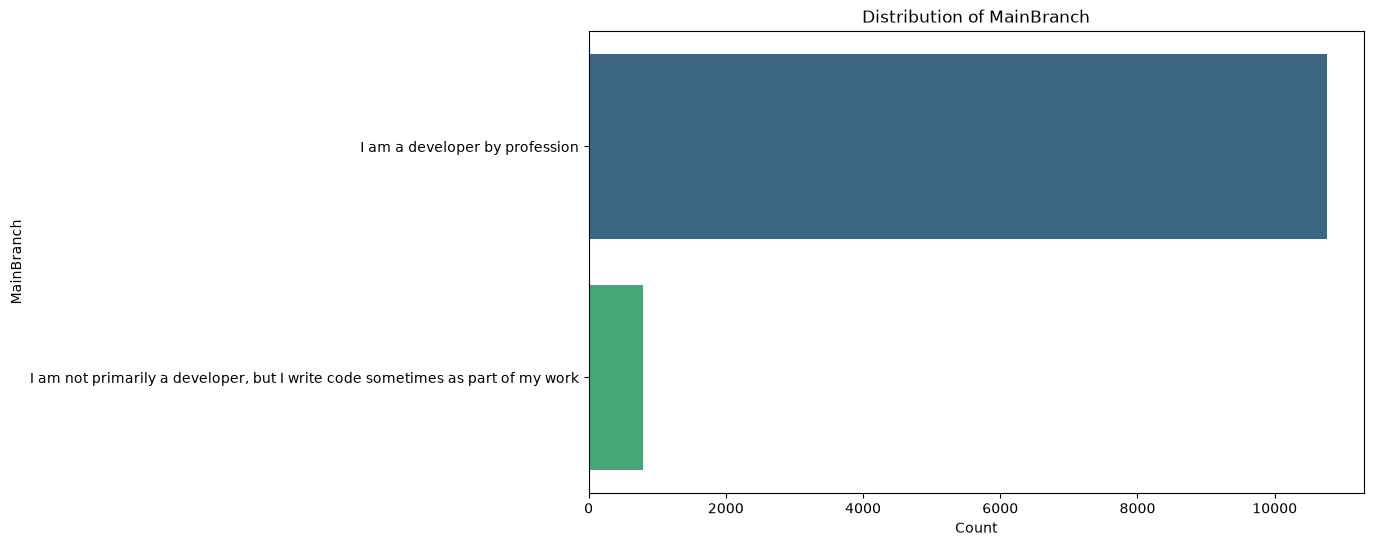

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

main_branch_counts = df['MainBranch'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=main_branch_counts.values, 
    y=main_branch_counts.index, 
    hue=main_branch_counts.index, 
    palette='viridis', 
    legend=False
)
plt.title('Distribution of MainBranch')
plt.xlabel('Count')
plt.ylabel('MainBranch')

plt.savefig('temp_plot.png', bbox_inches='tight')
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
